# 데이터 불러오기

In [1]:
import pandas as pd
import numpy as np

In [2]:
df_train = pd.read_csv('./data/churn_train.csv')
df_train.head()

,Customer_ID,Age,Tenure_Months,Monthly_Fee,Total_Usage_GB,Support_Tickets_3M,Late_Payments_6M,Contract,AutoPay,Internet_Type,Has_Addon,NPS_Score,Region,Churn
0,22216,38,1,70096,449,1,0,Month-to-month,1,DSL,1,-57,Seoul,0
1,22583,33,11,38262,564,2,1,Month-to-month,0,Fiber,0,69,Seoul,1
2,21663,27,34,62086,362,1,0,Month-to-month,1,Fiber,1,21,Metro,1
3,23028,56,19,72615,595,0,0,1-year,0,DSL,0,16,Seoul,0
4,24344,31,62,63279,365,2,1,2-year,0,5G,0,13,Metro,0


In [3]:
df_train.info()
# 결측치 없음.
# Age : 고객의 나이 - std
# Tenure_Months : 가입 후 이용기간 - std
# Monthly_Fee : 월 이용요금 -std
# Total_Usage_GB : 총 데이터 사용량 - std
# Support_Ticket_3M : 최근 3개월 간 문의 건수 - std
# Late_Payments_6M : 최근 6개월 간 요금 연체 건수 - std
# Contract : 계약 형태 - ohe
# Autopay : 자동이체 사용여부 - bool 형태로 되어있음
# Internet_Type : 인터넷 회선 유형 - ohe
# Has_Addon : 부가서비스 가입 여부 - bool 형태
# NPS_Score : 고객의 추천 의향/만족도를 수치화한 값
# Region : 고객의 거주 지역
# Churn : 이탈 여부 <- label(target) 값

<class 'pandas.DataFrame'>
RangeIndex: 6400 entries, 0 to 6399
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Customer_ID         6400 non-null   int64
 1   Age                 6400 non-null   int64
 2   Tenure_Months       6400 non-null   int64
 3   Monthly_Fee         6400 non-null   int64
 4   Total_Usage_GB      6400 non-null   int64
 5   Support_Tickets_3M  6400 non-null   int64
 6   Late_Payments_6M    6400 non-null   int64
 7   Contract            6400 non-null   str  
 8   AutoPay             6400 non-null   int64
 9   Internet_Type       6400 non-null   str  
 10  Has_Addon           6400 non-null   int64
 11  NPS_Score           6400 non-null   int64
 12  Region              6400 non-null   str  
 13  Churn               6400 non-null   int64
dtypes: int64(11), str(3)
memory usage: 819.8 KB


In [4]:
df_train.describe()

,Customer_ID,Age,Tenure_Months,Monthly_Fee,Total_Usage_GB,Support_Tickets_3M,Late_Payments_6M,AutoPay,Has_Addon,NPS_Score,Churn
count,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000
mean,23986.418906,43.295313,20.120781,68503.549844,378.990781,0.817500,0.510938,0.553281,0.446562,19.616875,0.259531
std,2320.146022,15.037027,13.974413,11963.755134,140.174917,0.900143,0.700192,0.497192,0.497175,34.573590,0.438412
min,20001.000000,18.000000,1.000000,35000.000000,30.000000,0.000000,0.000000,0.000000,0.000000,-94.000000,0.000000
25%,21957.750000,30.000000,10.000000,60485.500000,284.000000,0.000000,0.000000,0.000000,0.000000,-4.000000,0.000000
50%,23984.000000,43.000000,17.000000,68433.000000,379.000000,1.000000,0.000000,1.000000,0.000000,19.000000,0.000000
75%,26010.250000,56.000000,27.000000,76443.750000,474.000000,1.000000,1.000000,1.000000,1.000000,43.000000,1.000000
max,28000.000000,69.000000,72.000000,110676.000000,900.000000,6.000000,4.000000,1.000000,1.000000,100.000000,1.000000


In [5]:
df_train['Internet_Type'].value_counts()

Internet_Type
Fiber    3149
DSL      1977
5G       1274
Name: count, dtype: int64

In [6]:
df_train['Region'].value_counts()

Region
Metro    2520
Seoul    2185
Other    1695
Name: count, dtype: int64

In [7]:
df_train['Contract'].value_counts()

Contract
Month-to-month    3493
1-year            1975
2-year             932
Name: count, dtype: int64

In [8]:
df_train['NPS_Score'].unique()

array([-57,  69,  21,  16,  13,  73,   1, -38,  44,  65, -11,  12,  33,
        38, -32,  49,  84,  72,  97,  68, -22,  42,  -5,  -6,  31,   2,
        29,  20, -27, -15,  -7, -46, -14,  32,  51, -13,  62,  -1, -31,
        36, -64,  75,  47,  55, -43,  -2,  53,  56,   6,  60, -19, -68,
        58,  -3,  76,   4,  61,  27,  19,  92,  -8,  63,  30,  25,  23,
        45,  39, -25, 100,  67, -51,   3,  11,  66,  96,   7, -21,  18,
        28, -18,  83,  15,  43,  64, -26,   9, -28,  17,  40,  41,  26,
        -4,  59, -10,  50,  24,  74, -33,  34,   8,   5, -56,  57, -52,
        10,  14,  77,  46, -30, -20,  37,  88,  52, -35,   0, -44,  82,
        48,  54,  81,  90, -45,  -9,  80, -39, -17, -41,  22, -62, -34,
       -72, -58,  99, -29, -24,  35, -40,  87,  94, -84, -12, -37, -36,
       -16,  70, -55, -71,  98, -50,  91, -60,  86, -88, -59, -23, -61,
       -65,  71, -42, -47,  95,  78,  89,  85, -66, -54,  93, -69,  79,
       -73, -82, -48, -93, -53, -70, -75, -49, -74, -76, -78, -7

In [9]:
df_train = df_train.drop('Customer_ID', axis=1)

# 이상치 확인

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='Monthly_Fee', ylabel='Count'>

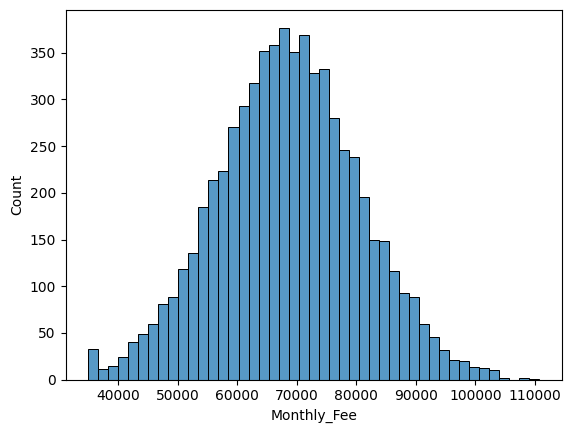

In [11]:
sns.histplot(df_train['Monthly_Fee'])

<Axes: xlabel='Tenure_Months', ylabel='Count'>

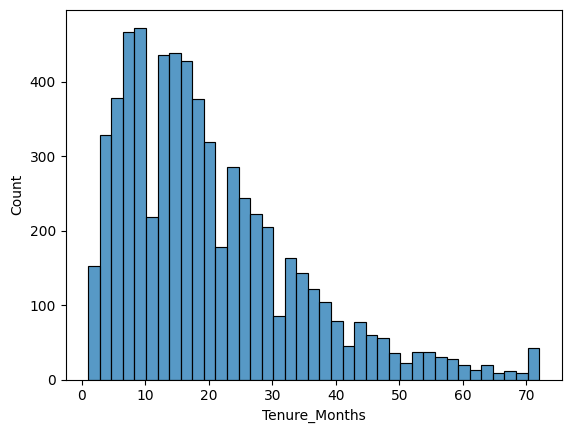

In [12]:
sns.histplot(df_train['Tenure_Months'])

# 데이터 나누기

In [13]:
X_train = df_train.drop('Churn', axis=1)
y_train = df_train['Churn']

In [14]:
print(X_train.shape, y_train.shape)

(6400, 12) (6400,)


In [15]:
# 표준화용 컬럼
std_train = X_train[['Age','Tenure_Months', 'Total_Usage_GB', 'Support_Tickets_3M', 'NPS_Score', 'Monthly_Fee', 'Late_Payments_6M']]
std_train

,Age,Tenure_Months,Total_Usage_GB,Support_Tickets_3M,NPS_Score,Monthly_Fee,Late_Payments_6M
0,38,1,449,1,-57,70096,0
1,33,11,564,2,69,38262,1
2,27,34,362,1,21,62086,0
3,56,19,595,0,16,72615,0
4,31,62,365,2,13,63279,1
...,...,...,...,...,...,...,...
6395,63,8,223,0,50,53721,1
6396,34,25,582,0,78,63161,0
6397,57,4,412,0,4,75455,0
6398,30,5,353,2,100,64100,0


In [16]:
# 원핫인코딩용 컬럼
ohe_train = X_train.select_dtypes(include=['object', 'str'])
ohe_train

,Contract,Internet_Type,Region
0,Month-to-month,DSL,Seoul
1,Month-to-month,Fiber,Seoul
2,Month-to-month,Fiber,Metro
3,1-year,DSL,Seoul
4,2-year,5G,Metro
...,...,...,...
6395,Month-to-month,Fiber,Seoul
6396,1-year,5G,Other
6397,2-year,DSL,Other
6398,1-year,Fiber,Seoul


# 스케일링

## 원핫인코딩

In [17]:
ohe_train

,Contract,Internet_Type,Region
0,Month-to-month,DSL,Seoul
1,Month-to-month,Fiber,Seoul
2,Month-to-month,Fiber,Metro
3,1-year,DSL,Seoul
4,2-year,5G,Metro
...,...,...,...
6395,Month-to-month,Fiber,Seoul
6396,1-year,5G,Other
6397,2-year,DSL,Other
6398,1-year,Fiber,Seoul


In [18]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
# handle_unknown="ignore" : 학습(fit) 때 없던 새로운 범주가 테스트(transform) 때 나와도 에러를 내지 않고 무시
# sparse_output=False : 원-핫 인코딩 결과를 희소 행렬(sparse matrix) 이 아니라 일반적인 밀집 배열(dense array, numpy ndarray) 로 반환

In [19]:
# 인코딩
X_train_ohe = ohe.fit_transform(ohe_train)
X_train_ohe

array([[0., 0., 1., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 1.],
       [0., 0., 1., ..., 1., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 1.]], shape=(6400, 9))

In [20]:
# 데이터 프레임용 컬럼명 추출
ohe_cols = ohe.get_feature_names_out(ohe_train.columns)
ohe_cols

array(['Contract_1-year', 'Contract_2-year', 'Contract_Month-to-month',
       'Internet_Type_5G', 'Internet_Type_DSL', 'Internet_Type_Fiber',
       'Region_Metro', 'Region_Other', 'Region_Seoul'], dtype=object)

In [21]:
# 인코딩 결과를 데이터 프레임으로 만들기
df_ohe = pd.DataFrame(X_train_ohe, columns=ohe_cols, index=X_train.index)
df_ohe

,Contract_1-year,Contract_2-year,Contract_Month-to-month,Internet_Type_5G,Internet_Type_DSL,Internet_Type_Fiber,Region_Metro,Region_Other,Region_Seoul
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
6395,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
6396,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
6397,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6398,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [ ]:
# X_train 데이터프레임에 인코딩 결과를 합치기
X_train = pd.concat([X_train.drop(columns=ohe_train), df_ohe], axis=1)

In [23]:
X_train

,Age,Tenure_Months,Monthly_Fee,Total_Usage_GB,Support_Tickets_3M,Late_Payments_6M,AutoPay,Has_Addon,NPS_Score,Contract_1-year,Contract_2-year,Contract_Month-to-month,Internet_Type_5G,Internet_Type_DSL,Internet_Type_Fiber,Region_Metro,Region_Other,Region_Seoul
0,38,1,70096,449,1,0,1,1,-57,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,33,11,38262,564,2,1,0,0,69,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,27,34,62086,362,1,0,1,1,21,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
3,56,19,72615,595,0,0,0,0,16,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,31,62,63279,365,2,1,0,0,13,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6395,63,8,53721,223,0,1,1,0,50,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
6396,34,25,63161,582,0,0,0,1,78,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
6397,57,4,75455,412,0,0,0,0,4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6398,30,5,64100,353,2,0,1,1,100,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


## 표준화

In [24]:
std_train

,Age,Tenure_Months,Total_Usage_GB,Support_Tickets_3M,NPS_Score,Monthly_Fee,Late_Payments_6M
0,38,1,449,1,-57,70096,0
1,33,11,564,2,69,38262,1
2,27,34,362,1,21,62086,0
3,56,19,595,0,16,72615,0
4,31,62,365,2,13,63279,1
...,...,...,...,...,...,...,...
6395,63,8,223,0,50,53721,1
6396,34,25,582,0,78,63161,0
6397,57,4,412,0,4,75455,0
6398,30,5,353,2,100,64100,0


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [26]:
X_train_std = scaler.fit_transform(std_train)
X_train_std

array([[-0.35217907, -1.36837775,  0.49948086, ..., -2.21622521,
         0.13311661, -0.7297671 ],
       [-0.68471759, -0.65272825,  1.31994852, ...,  1.42845981,
        -2.52796153,  0.69852325],
       [-1.08376381,  0.99326559, -0.12122075, ...,  0.04000837,
        -0.53645793, -0.7297671 ],
       ...,
       [ 0.91146729, -1.1536829 ,  0.23550432, ..., -0.45173484,
         0.5810879 , -0.7297671 ],
       [-0.8842407 , -1.08211795, -0.18543126, ...,  2.32516803,
        -0.36810298, -0.7297671 ],
       [-0.75122529, -0.4380334 ,  0.11421779, ..., -1.75340807,
        -0.46498649, -0.7297671 ]], shape=(6400, 7))

In [27]:
df_std = pd.DataFrame(X_train_std, columns=std_train.columns, index=X_train.index)
df_std

,Age,Tenure_Months,Total_Usage_GB,Support_Tickets_3M,NPS_Score,Monthly_Fee,Late_Payments_6M
0,-0.352179,-1.368378,0.499481,0.202761,-2.216225,0.133117,-0.729767
1,-0.684718,-0.652728,1.319949,1.313782,1.428460,-2.527962,0.698523
2,-1.083764,0.993266,-0.121221,0.202761,0.040008,-0.536458,-0.729767
3,0.844960,-0.080209,1.541118,-0.908260,-0.104622,0.343686,-0.729767
4,-0.817733,2.997084,-0.099817,1.313782,-0.191400,-0.436732,0.698523
...,...,...,...,...,...,...,...
6395,1.310514,-0.867423,-1.112916,-0.908260,0.878864,-1.235708,0.698523
6396,-0.618210,0.349181,1.448370,-0.908260,1.688794,-0.446596,-0.729767
6397,0.911467,-1.153683,0.235504,-0.908260,-0.451735,0.581088,-0.729767
6398,-0.884241,-1.082118,-0.185431,1.313782,2.325168,-0.368103,-0.729767


In [28]:
X_train = pd.concat([X_train.drop(columns=std_train), df_std], axis=1)

In [29]:
X_train

,AutoPay,Has_Addon,Contract_1-year,Contract_2-year,Contract_Month-to-month,Internet_Type_5G,Internet_Type_DSL,Internet_Type_Fiber,Region_Metro,Region_Other,Region_Seoul,Age,Tenure_Months,Total_Usage_GB,Support_Tickets_3M,NPS_Score,Monthly_Fee,Late_Payments_6M
0,1,1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.352179,-1.368378,0.499481,0.202761,-2.216225,0.133117,-0.729767
1,0,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.684718,-0.652728,1.319949,1.313782,1.428460,-2.527962,0.698523
2,1,1,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,-1.083764,0.993266,-0.121221,0.202761,0.040008,-0.536458,-0.729767
3,0,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.844960,-0.080209,1.541118,-0.908260,-0.104622,0.343686,-0.729767
4,0,0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,-0.817733,2.997084,-0.099817,1.313782,-0.191400,-0.436732,0.698523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6395,1,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.310514,-0.867423,-1.112916,-0.908260,0.878864,-1.235708,0.698523
6396,0,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.618210,0.349181,1.448370,-0.908260,1.688794,-0.446596,-0.729767
6397,0,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.911467,-1.153683,0.235504,-0.908260,-0.451735,0.581088,-0.729767
6398,1,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.884241,-1.082118,-0.185431,1.313782,2.325168,-0.368103,-0.729767


In [ ]:
# 스케일링 확인
# int가 있어도 괜찮은가?
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 6400 entries, 0 to 6399
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   AutoPay                  6400 non-null   int64  
 1   Has_Addon                6400 non-null   int64  
 2   Contract_1-year          6400 non-null   float64
 3   Contract_2-year          6400 non-null   float64
 4   Contract_Month-to-month  6400 non-null   float64
 5   Internet_Type_5G         6400 non-null   float64
 6   Internet_Type_DSL        6400 non-null   float64
 7   Internet_Type_Fiber      6400 non-null   float64
 8   Region_Metro             6400 non-null   float64
 9   Region_Other             6400 non-null   float64
 10  Region_Seoul             6400 non-null   float64
 11  Age                      6400 non-null   float64
 12  Tenure_Months            6400 non-null   float64
 13  Total_Usage_GB           6400 non-null   float64
 14  Support_Tickets_3M       6400 non-n

In [31]:
print(X_train.shape, y_train.shape)

(6400, 18) (6400,)


# Test Data

## 데이터 불러오기

In [32]:
df_test = pd.read_csv("./data/churn_test.csv")
df_test.head()

,Customer_ID,Age,Tenure_Months,Monthly_Fee,Total_Usage_GB,Support_Tickets_3M,Late_Payments_6M,Contract,AutoPay,Internet_Type,Has_Addon,NPS_Score,Region,Churn
0,26891,25,6,62606,450,0,1,Month-to-month,0,Fiber,0,12,Seoul,0
1,27712,29,8,57140,437,0,1,2-year,0,DSL,0,-9,Metro,0
2,25001,28,17,68910,466,2,1,Month-to-month,0,Fiber,0,24,Seoul,0
3,25854,53,23,64286,494,2,0,Month-to-month,1,Fiber,1,72,Metro,0
4,21280,63,12,62359,129,0,0,Month-to-month,1,5G,0,-41,Other,0


In [33]:
df_test = df_test.drop('Customer_ID', axis=1)

In [34]:
X_test = df_test.drop('Churn', axis=1)
y_test = df_test['Churn']

In [35]:
print(X_test.shape, y_test.shape)

(1600, 12) (1600,)


In [36]:
std_test = X_test[['Age','Tenure_Months', 'Total_Usage_GB', 'Support_Tickets_3M', 'NPS_Score', 'Monthly_Fee', 'Late_Payments_6M']]
std_test

,Age,Tenure_Months,Total_Usage_GB,Support_Tickets_3M,NPS_Score,Monthly_Fee,Late_Payments_6M
0,25,6,450,0,12,62606,1
1,29,8,437,0,-9,57140,1
2,28,17,466,2,24,68910,1
3,53,23,494,2,72,64286,0
4,63,12,129,0,-41,62359,0
...,...,...,...,...,...,...,...
1595,34,16,569,0,12,38494,0
1596,27,25,365,2,13,51303,2
1597,68,9,456,2,78,57609,0
1598,28,58,199,0,-27,58553,2


In [37]:
ohe_test = X_test.select_dtypes(include=['object', 'str'])
ohe_test

,Contract,Internet_Type,Region
0,Month-to-month,Fiber,Seoul
1,2-year,DSL,Metro
2,Month-to-month,Fiber,Seoul
3,Month-to-month,Fiber,Metro
4,Month-to-month,5G,Other
...,...,...,...
1595,1-year,Fiber,Seoul
1596,1-year,DSL,Seoul
1597,Month-to-month,DSL,Seoul
1598,Month-to-month,Fiber,Seoul


# 스케일링

In [ ]:
# test 데이터에 같은 전처리 과정을 거친다.

## 원핫인코딩

In [38]:
ohe_test

,Contract,Internet_Type,Region
0,Month-to-month,Fiber,Seoul
1,2-year,DSL,Metro
2,Month-to-month,Fiber,Seoul
3,Month-to-month,Fiber,Metro
4,Month-to-month,5G,Other
...,...,...,...
1595,1-year,Fiber,Seoul
1596,1-year,DSL,Seoul
1597,Month-to-month,DSL,Seoul
1598,Month-to-month,Fiber,Seoul


In [39]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

In [40]:
X_test_ohe = ohe.fit_transform(ohe_test)
X_test_ohe

array([[0., 0., 1., ..., 0., 0., 1.],
       [0., 1., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 1.],
       ...,
       [0., 0., 1., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 1.],
       [1., 0., 0., ..., 1., 0., 0.]], shape=(1600, 9))

In [41]:
ohe_cols_test = ohe.get_feature_names_out(ohe_test.columns)
ohe_cols_test

array(['Contract_1-year', 'Contract_2-year', 'Contract_Month-to-month',
       'Internet_Type_5G', 'Internet_Type_DSL', 'Internet_Type_Fiber',
       'Region_Metro', 'Region_Other', 'Region_Seoul'], dtype=object)

In [42]:
df_test_ohe = pd.DataFrame(X_test_ohe, columns=ohe_cols_test, index=X_test.index)
df_test_ohe

,Contract_1-year,Contract_2-year,Contract_Month-to-month,Internet_Type_5G,Internet_Type_DSL,Internet_Type_Fiber,Region_Metro,Region_Other,Region_Seoul
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
4,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
1595,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1596,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1597,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1598,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


In [43]:
X_test = pd.concat([X_test.drop(columns=ohe_test), df_test_ohe], axis=1)

## 표준화

In [44]:
std_test

,Age,Tenure_Months,Total_Usage_GB,Support_Tickets_3M,NPS_Score,Monthly_Fee,Late_Payments_6M
0,25,6,450,0,12,62606,1
1,29,8,437,0,-9,57140,1
2,28,17,466,2,24,68910,1
3,53,23,494,2,72,64286,0
4,63,12,129,0,-41,62359,0
...,...,...,...,...,...,...,...
1595,34,16,569,0,12,38494,0
1596,27,25,365,2,13,51303,2
1597,68,9,456,2,78,57609,0
1598,28,58,199,0,-27,58553,2


In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [46]:
X_test_std = scaler.fit_transform(std_test)
X_test_std

array([[-1.22196787, -0.99196461,  0.48984765, ..., -0.19189749,
        -0.4124942 ,  0.72612854],
       [-0.95117166, -0.84793418,  0.39602698, ..., -0.79359174,
        -0.86532013,  0.72612854],
       [-1.01887071, -0.19979722,  0.60531924, ...,  0.1519278 ,
         0.10975509,  0.72612854],
       ...,
       [ 1.68909131, -0.77591896,  0.5331495 , ...,  1.69914159,
        -0.82646625, -0.71353152],
       [-1.01887071,  2.75282671, -1.32161301, ..., -1.30932967,
        -0.7482614 ,  2.1657886 ],
       [-0.68037546, -0.55987331, -1.27831116, ..., -0.53572278,
         0.56349231,  0.72612854]], shape=(1600, 7))

In [47]:
df_test_std = pd.DataFrame(X_test_std, columns=std_test.columns, index=X_test.index)
df_test_std

,Age,Tenure_Months,Total_Usage_GB,Support_Tickets_3M,NPS_Score,Monthly_Fee,Late_Payments_6M
0,-1.221968,-0.991965,0.489848,-0.889010,-0.191897,-0.412494,0.726129
1,-0.951172,-0.847934,0.396027,-0.889010,-0.793592,-0.865320,0.726129
2,-1.018871,-0.199797,0.605319,1.306077,0.151928,0.109755,0.726129
3,0.673606,0.232294,0.807395,1.306077,1.527229,-0.273316,-0.713532
4,1.350596,-0.559873,-1.826801,-0.889010,-1.710459,-0.432957,-0.713532
...,...,...,...,...,...,...,...
1595,-0.612676,-0.271812,1.348668,-0.889010,-0.191897,-2.410031,-0.713532
1596,-1.086570,0.376325,-0.123595,1.306077,-0.163245,-1.348881,2.165789
1597,1.689091,-0.775919,0.533149,1.306077,1.699142,-0.826466,-0.713532
1598,-1.018871,2.752827,-1.321613,-0.889010,-1.309330,-0.748261,2.165789


In [48]:
X_test = pd.concat([X_test.drop(columns=std_test), df_test_std], axis=1)

In [49]:
X_test

,AutoPay,Has_Addon,Contract_1-year,Contract_2-year,Contract_Month-to-month,Internet_Type_5G,Internet_Type_DSL,Internet_Type_Fiber,Region_Metro,Region_Other,Region_Seoul,Age,Tenure_Months,Total_Usage_GB,Support_Tickets_3M,NPS_Score,Monthly_Fee,Late_Payments_6M
0,0,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,-1.221968,-0.991965,0.489848,-0.889010,-0.191897,-0.412494,0.726129
1,0,0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,-0.951172,-0.847934,0.396027,-0.889010,-0.793592,-0.865320,0.726129
2,0,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,-1.018871,-0.199797,0.605319,1.306077,0.151928,0.109755,0.726129
3,1,1,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.673606,0.232294,0.807395,1.306077,1.527229,-0.273316,-0.713532
4,1,0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.350596,-0.559873,-1.826801,-0.889010,-1.710459,-0.432957,-0.713532
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,0,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,-0.612676,-0.271812,1.348668,-0.889010,-0.191897,-2.410031,-0.713532
1596,1,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-1.086570,0.376325,-0.123595,1.306077,-0.163245,-1.348881,2.165789
1597,0,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.689091,-0.775919,0.533149,1.306077,1.699142,-0.826466,-0.713532
1598,0,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,-1.018871,2.752827,-1.321613,-0.889010,-1.309330,-0.748261,2.165789


In [50]:
X_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   AutoPay                  1600 non-null   int64  
 1   Has_Addon                1600 non-null   int64  
 2   Contract_1-year          1600 non-null   float64
 3   Contract_2-year          1600 non-null   float64
 4   Contract_Month-to-month  1600 non-null   float64
 5   Internet_Type_5G         1600 non-null   float64
 6   Internet_Type_DSL        1600 non-null   float64
 7   Internet_Type_Fiber      1600 non-null   float64
 8   Region_Metro             1600 non-null   float64
 9   Region_Other             1600 non-null   float64
 10  Region_Seoul             1600 non-null   float64
 11  Age                      1600 non-null   float64
 12  Tenure_Months            1600 non-null   float64
 13  Total_Usage_GB           1600 non-null   float64
 14  Support_Tickets_3M       1600 non-n

# 모델 학습

In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,f1_score,classification_report, confusion_matrix

In [52]:
model_tree = DecisionTreeClassifier(random_state=3333)

In [53]:
model_tree.fit(X_train, y_train)

pred = model_tree.predict(X_test)

accuracy_score(y_test, pred)

0.670625

In [54]:
model_rf = RandomForestClassifier(random_state=3333, n_estimators=1000, n_jobs=-1)
model_rf.fit(X_train,y_train)
pred = model_rf.predict(X_test)
accuracy_score(y_test, pred)

0.78625

In [55]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier(n_estimators=1000, learning_rate=0.05, max_depth=3, eval_metric='logloss')

In [56]:
xgb_model.fit(X_train,y_train)
pred = xgb_model.predict(X_test)
accuracy_score(pred,y_test)


0.78125